In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn joblib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 204.1 kB/s eta 0:00:44
   -- ----------


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Nota:** Esta celda solo instala las librerías que se van a usar más adelante (pandas, numpy, matplotlib, seaborn, scikit-learn y joblib).

## 1. Importación de librerías
Se importan las librerías necesarias para el análisis de datos (`pandas`, `numpy`), la visualización (`matplotlib`, `seaborn`), el preprocesamiento y el modelo de regresión lineal, así como las métricas de evaluación de `scikit-learn`.


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score  , mean_absolute_error
from sklearn.metrics import confusion_matrix

plt.style.use("fivethirtyeight")

## 2. Carga del dataset
Se lee el archivo CSV con los datos de rendimiento estudiantil y se carga en un DataFrame de pandas.


In [4]:
df=pd.read_csv(r"Student_Performance.csv")

**Nota:** En esta parte se carga el archivo CSV con los datos y se guarda en `df`, que es la tabla con la que se va a trabajar todo el notebook.


## 3. Exploración inicial de los datos
Se inspecciona el DataFrame, se verifica si existen valores nulos y filas duplicadas, y se eliminan las duplicadas encontradas.


In [6]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [7]:
df.isna().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(127)

In [9]:
df.drop_duplicates(inplace=True)

## 4. Análisis de 'Horas Estudiadas'
Se revisa la distribución de la cantidad de horas estudiadas mediante un conteo de valores y un gráfico de barras con el porcentaje que representa cada valor.


In [10]:
df["Hours Studied"].value_counts()

Hours Studied
1    1133
6    1122
7    1118
3    1110
9    1099
2    1077
8    1074
4    1071
5    1069
Name: count, dtype: int64

C:\Users\DELL\AppData\Local\Temp\ipykernel_6684\454229306.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.countplot(x="Hours Studied", data=df, palette="coolwarm")


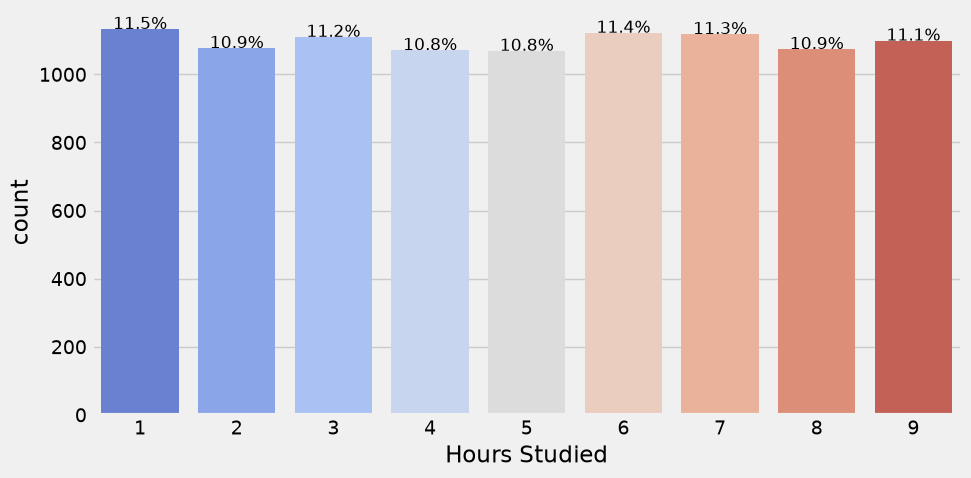

In [11]:
plt.figure(figsize=(10,5))
bar_plot = sns.countplot(x="Hours Studied", data=df, palette="coolwarm")
total = len(df["Hours Studied"])

for p in bar_plot.patches:
    bar_plot.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.5,
                  f'{(p.get_height() / total) * 100:.1f}%', ha='center', fontsize=12)

plt.show()


**Nota:** Se ve cuántas veces aparece cada valor de "horas estudiadas" y se grafica en barras con el porcentaje que representa cada una. Sirve para tener una idea rápida de cómo se distribuyen los datos de esta columna.


## 5. Análisis de 'Puntajes Anteriores'
Se calculan estadísticas descriptivas de los puntajes anteriores, se visualiza su distribución con un histograma y se agrupan los valores en rangos (bins) para contar cuántos estudiantes caen en cada uno.


In [12]:
df["Previous Scores"].describe()

count    9873.000000
mean       69.441102
std        17.325601
min        40.000000
25%        54.000000
50%        69.000000
75%        85.000000
max        99.000000
Name: Previous Scores, dtype: float64

<Axes: xlabel='Previous Scores', ylabel='Count'>

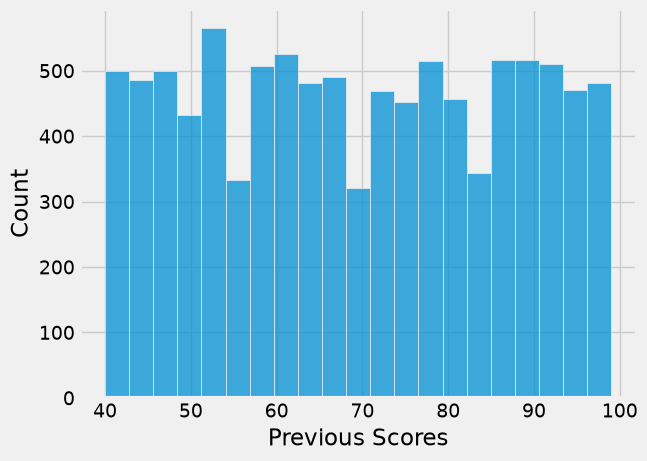

In [13]:
sns.histplot(x= df["Previous Scores"])

In [14]:
cut_series = pd.cut(df["Previous Scores"], bins=[40, 50, 60, 70, 80, 90, 100], labels=['40-50', '50-60', '60-70', '70-80', '80-90', '90-100'])
value_counts = cut_series.value_counts().sort_index()

value_counts.reset_index()


,Previous Scores,count
0,40-50,1609
1,50-60,1726
2,60-70,1637
3,70-80,1587
4,80-90,1680
5,90-100,1463


## 6. Análisis de 'Actividades Extracurriculares'
Se cuenta cuántos estudiantes participan o no en actividades extracurriculares y se visualiza la proporción con un gráfico de pastel (dona).


In [15]:
df["Extracurricular Activities"].value_counts()

Extracurricular Activities
No     4986
Yes    4887
Name: count, dtype: int64

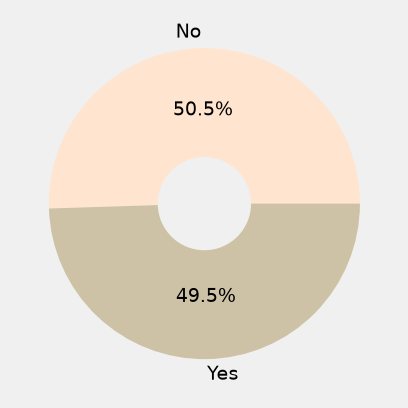

In [16]:
df["Extracurricular Activities"].value_counts().plot(kind ="pie" , autopct='%1.1f%%', colors=["#FFE5CF" , "#CDC2A5"], explode=(0,0), wedgeprops=dict(width=0.7));

## 7. Análisis de 'Horas de Sueño'
Se obtienen estadísticas descriptivas de las horas de sueño y se muestra la distribución de sus valores con un gráfico de barras.


In [17]:
df["Sleep Hours"].describe()

count    9873.000000
mean        6.531652
std         1.697683
min         4.000000
25%         5.000000
50%         7.000000
75%         8.000000
max         9.000000
Name: Sleep Hours, dtype: float64

In [18]:
df["Sleep Hours"].value_counts()

Sleep Hours
8    1784
7    1653
6    1645
9    1606
4    1605
5    1580
Name: count, dtype: int64

C:\Users\DELL\AppData\Local\Temp\ipykernel_6684\3197358435.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.countplot(x="Sleep Hours", data=df, palette="coolwarm")


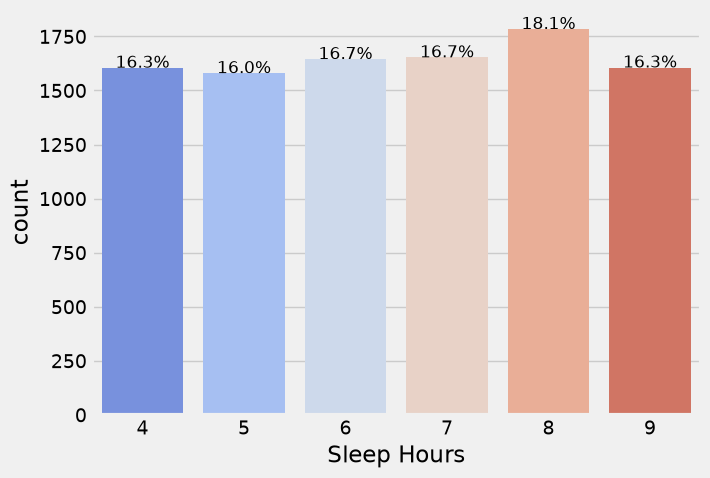

In [19]:
plt.figure(figsize=(7,5))
bar_plot = sns.countplot(x="Sleep Hours", data=df, palette="coolwarm")
total = len(df["Sleep Hours"])

for p in bar_plot.patches:
    bar_plot.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.5,
                  f'{(p.get_height() / total) * 100:.1f}%', ha='center', fontsize=12)

plt.show()


## 8. Análisis de 'Cuestionarios de Práctica Realizados'
Se cuenta la cantidad de cuestionarios de práctica realizados por los estudiantes y se visualiza su distribución con un gráfico de barras.


In [20]:
df["Sample Question Papers Practiced"].value_counts()

Sample Question Papers Practiced
6    1046
9    1038
3    1020
5    1018
8    1016
1     969
7     967
4     945
0     937
2     917
Name: count, dtype: int64

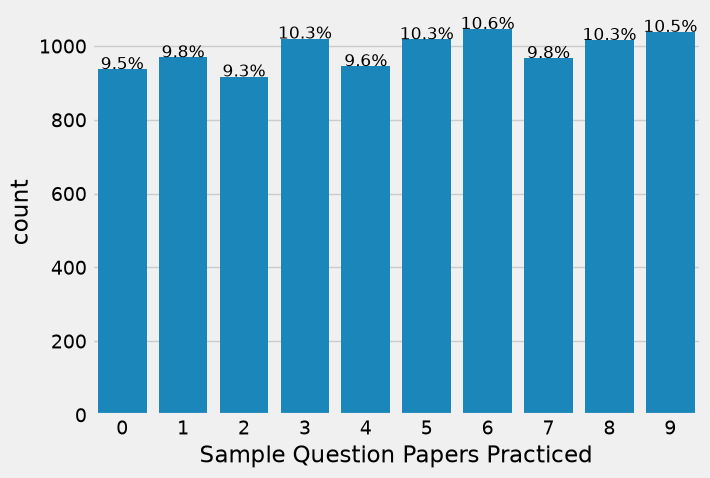

In [21]:
plt.figure(figsize=(7,5))
bar_plot = sns.countplot(x="Sample Question Papers Practiced", data=df)
total = len(df["Sample Question Papers Practiced"])

for p in bar_plot.patches:
    bar_plot.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.5,
                  f'{(p.get_height() / total) * 100:.1f}%', ha='center', fontsize=12)

plt.show()


## 9. Análisis de la variable objetivo: 'Índice de Rendimiento'
Se calculan estadísticas descriptivas del índice de rendimiento (la variable que se quiere predecir) y se examina su distribución con un histograma.


In [22]:
df["Performance Index"].describe()

count    9873.000000
mean       55.216651
std        19.208570
min        10.000000
25%        40.000000
50%        55.000000
75%        70.000000
max       100.000000
Name: Performance Index, dtype: float64

<Axes: xlabel='Performance Index', ylabel='Count'>

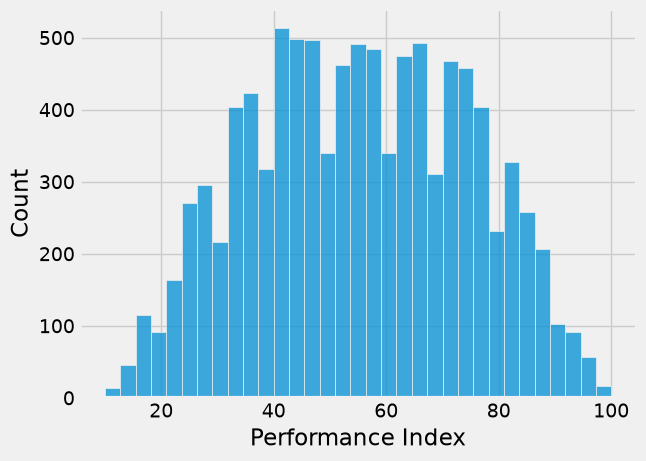

In [23]:
sns.histplot(x= df["Performance Index"])

**Nota:** Esta es la variable que se quiere predecir al final (el índice de rendimiento), así que se revisan sus estadísticas y se ve su distribución con un histograma antes de meterla al modelo.


## 10. Relación entre variables
Se exploran visualmente las relaciones entre distintas variables (horas estudiadas, puntajes anteriores, actividades extracurriculares, horas de sueño e índice de rendimiento) mediante gráficos de líneas, barras agrupadas, histogramas superpuestos y un diagrama de dispersión.


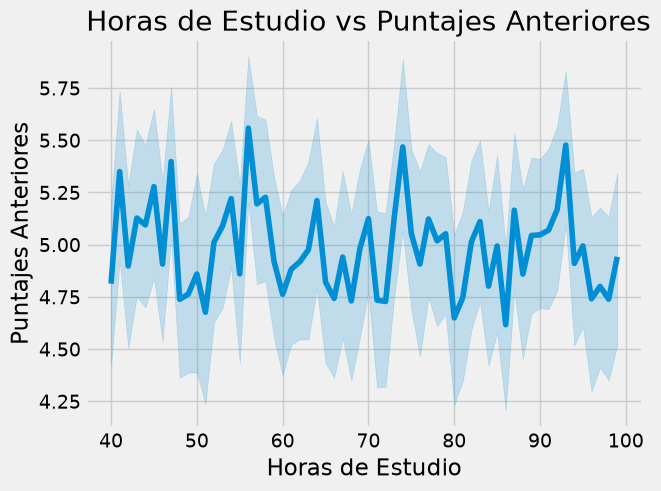

In [24]:
sns.lineplot(y=df['Hours Studied'], x=df['Previous Scores'])
plt.xlabel('Horas de Estudio')
plt.ylabel('Puntajes Anteriores')
plt.title(' Horas de Estudio vs Puntajes Anteriores')
plt.show()


In [25]:
df.groupby(["Extracurricular Activities"])["Hours Studied"].value_counts().unstack()

Hours Studied,1,2,3,4,5,6,7,8,9
Extracurricular Activities,,,,,,,,,
No,587,559,553,539,524,529,579,583,533
Yes,546,518,557,532,545,593,539,491,566


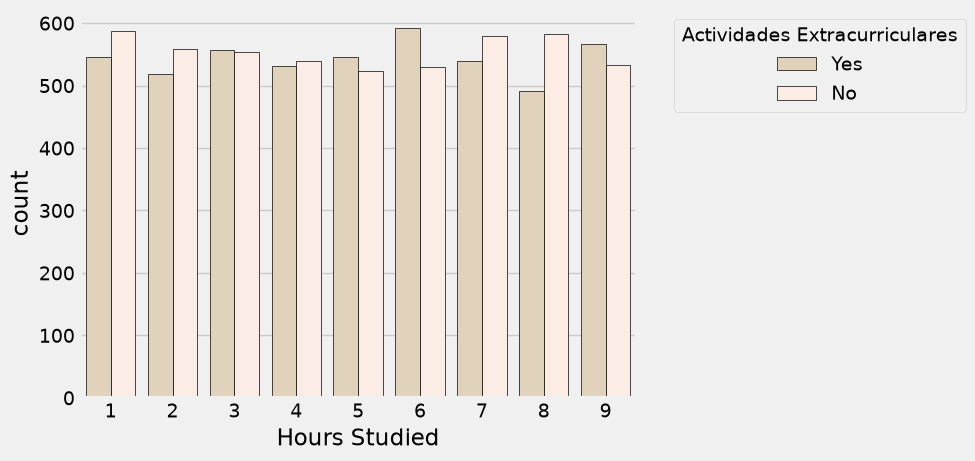

In [26]:
sns.countplot(data=df, hue="Extracurricular Activities", x="Hours Studied" ,  palette=["#E7D4B5" ,"#FEECE2"] ,edgecolor="black")
plt.legend(title='Actividades Extracurriculares', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

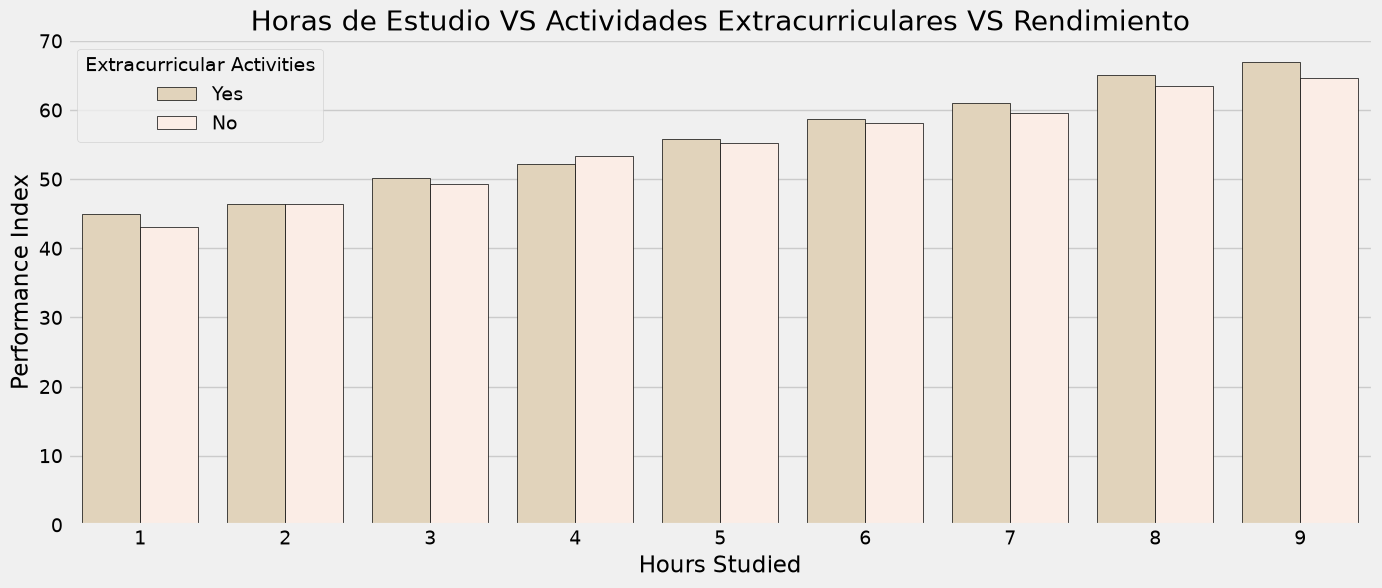

In [27]:
plt.figure(figsize=(15, 6))
sns.barplot(x='Hours Studied', y='Performance Index', data=df, hue='Extracurricular Activities',palette=["#E7D4B5" ,"#FEECE2"] , errorbar=None , edgecolor="black" )

plt.title('Horas de Estudio VS Actividades Extracurriculares VS Rendimiento')
plt.show()

In [28]:
grouped_data= df.groupby("Hours Studied")["Sleep Hours"].value_counts().unstack()
grouped_data

Sleep Hours,4,5,6,7,8,9
Hours Studied,,,,,,
1,170,177,175,199,233,179
2,200,157,200,166,176,178
3,192,177,182,178,188,193
4,166,163,180,186,207,169
5,163,182,183,181,205,155
6,207,187,183,182,190,173
7,168,170,184,189,211,196
8,168,197,195,172,175,167
9,171,170,163,200,199,196


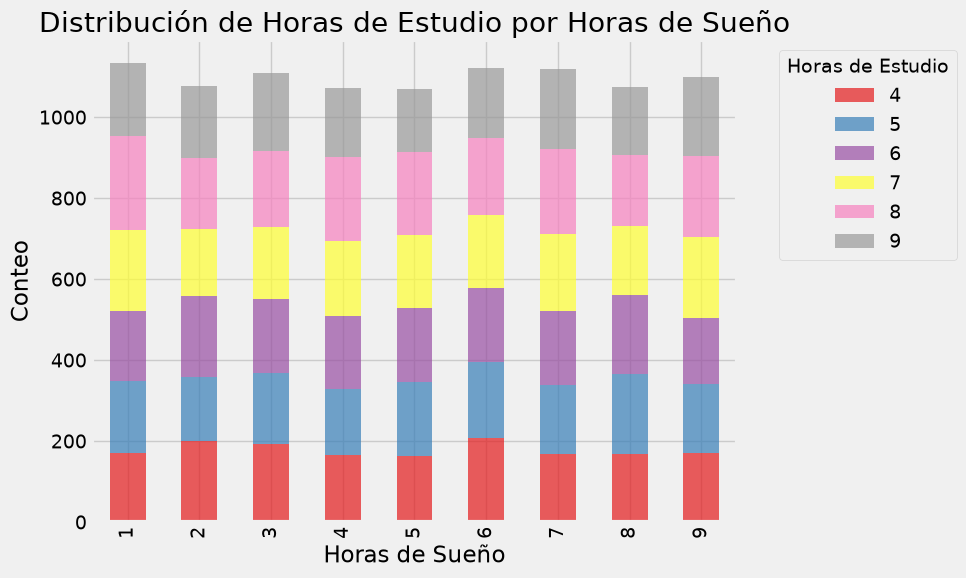

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear un DataFrame para agrupar los datos (se asume que los datos ya están en df)
grouped_data = df.groupby("Hours Studied")["Sleep Hours"].value_counts().unstack(fill_value=0)

# Graficar el gráfico apilado
plt.figure(figsize=(10, 6))

# Graficar el gráfico apilado usando bar
grouped_data.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='Set1', alpha=0.7)

# Agregar los títulos y formatos
plt.title('Distribución de Horas de Estudio por Horas de Sueño')
plt.xlabel('Horas de Sueño')
plt.ylabel('Conteo')
plt.legend(title='Horas de Estudio', bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar el diseño
plt.tight_layout()
plt.show()


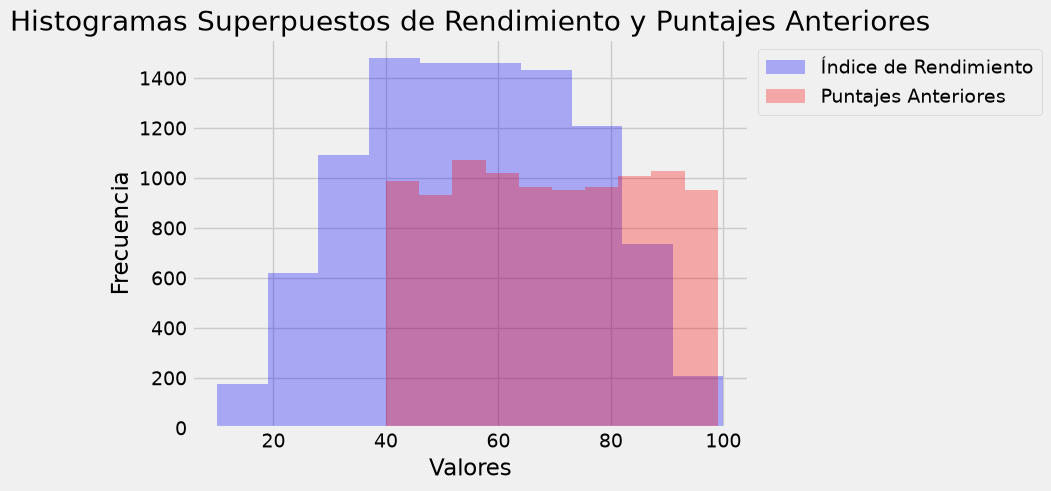

In [30]:
papers_practiced = df['Performance Index']
previous_scores = df['Previous Scores']

plt.hist(papers_practiced, bins=10, alpha=0.3, label='Índice de Rendimiento', color='blue')
plt.hist(previous_scores, bins=10, alpha=0.3, label='Puntajes Anteriores', color='red')

plt.xlabel('Valores')
plt.ylabel('Frecuencia')
plt.title('Histogramas Superpuestos de Rendimiento y Puntajes Anteriores')
plt.legend( bbox_to_anchor=(1, 1), loc='upper left')

plt.show()


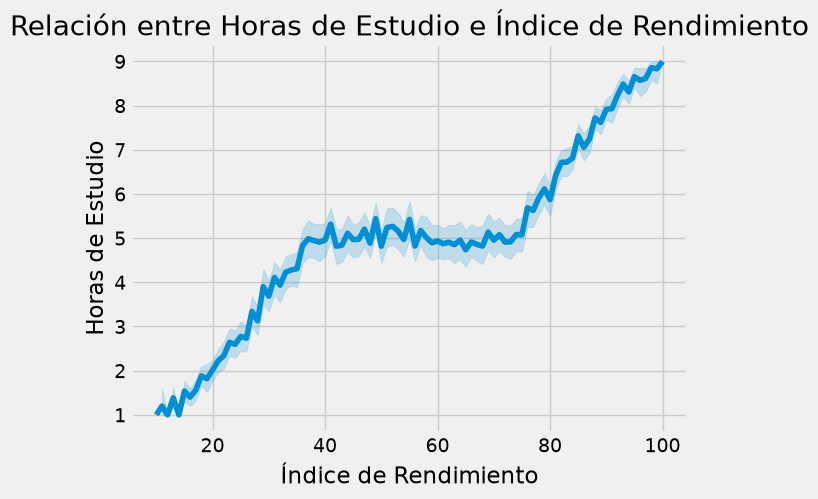

In [31]:
sns.lineplot(data=df, y='Hours Studied', x='Performance Index')

plt.title('Relación entre Horas de Estudio e Índice de Rendimiento')
plt.ylabel('Horas de Estudio')
plt.xlabel('Índice de Rendimiento')
plt.show()

<Axes: xlabel='Previous Scores', ylabel='Performance Index'>

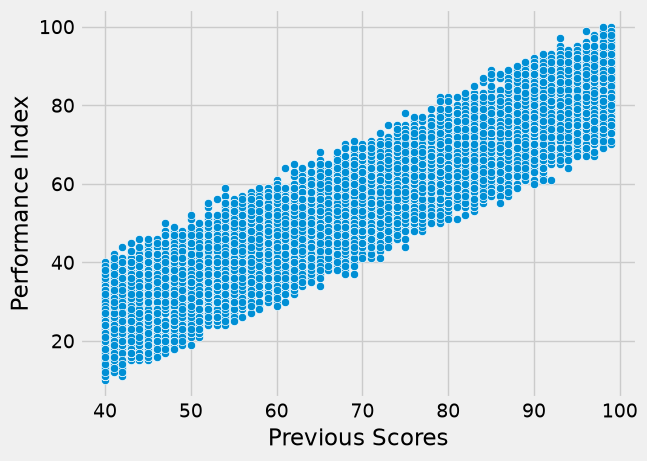

In [32]:
sns.scatterplot(x='Previous Scores' , y='Performance Index', data=df)


**Nota:** En esta sección se comparan varias variables entre sí con distintos gráficos (líneas, barras, histogramas superpuestos, dispersión) para ver si hay alguna relación visible entre ellas, por ejemplo si estudiar más horas se relaciona con mejor rendimiento. Es más que nada para explorar antes de armar el modelo.


# Aprendizaje automático 


## 11. Codificación de variables categóricas
La columna 'Actividades Extracurriculares' contiene valores de texto (Sí/No), por lo que se convierte a valores numéricos usando `LabelEncoder` para que pueda ser utilizada por el modelo.


In [33]:
label_encoder = LabelEncoder()

df['Extracurricular Activities'] = label_encoder.fit_transform(df['Extracurricular Activities'])


## 12. Separación en variables predictoras (X) y variable objetivo (y)
Se separa el DataFrame en las variables predictoras (`X`, todas las columnas excepto el índice de rendimiento) y la variable objetivo (`y`, el índice de rendimiento).


In [34]:
X = df.drop(columns=['Performance Index'])  
y = df['Performance Index']  


In [35]:
X

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5
...,...,...,...,...,...
9995,1,49,1,4,2
9996,7,64,1,8,5
9997,6,83,1,8,5
9998,9,97,1,7,0


In [36]:
y

0       91.0
1       65.0
2       45.0
3       36.0
4       66.0
        ... 
9995    23.0
9996    58.0
9997    74.0
9998    95.0
9999    64.0
Name: Performance Index, Length: 9873, dtype: float64

**Nota:** Aquí se separan los datos en dos partes: `X`, que son todas las columnas que se usan para predecir, y `y`, que es la columna que se quiere predecir (el índice de rendimiento).


## 13. Escalado de los datos
Se estandarizan las variables numéricas predictoras y la variable objetivo con `StandardScaler`, de modo que todas tengan una escala comparable antes de entrenar el modelo.


In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.drop(["Extracurricular Activities"] ,axis=1))
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))


**Nota:** Se escalan (normalizan) los datos con `StandardScaler`, tanto las variables predictoras como la variable objetivo. Esto es porque las columnas tienen escalas muy distintas (por ejemplo, horas de 0 a 9 vs. puntajes de 40 a 100) y así el modelo no le da más "peso" a una columna solo por tener números más grandes.


## 14. Recombinación de las variables
Se vuelve a unir la columna de 'Actividades Extracurriculares' con el resto de las variables predictoras escaladas.


In [38]:
column= X[["Extracurricular Activities"]]
X_combined = np.hstack((X_scaled, column.values))


**Nota:** Como la columna de actividades extracurriculares ya estaba en 0 y 1 (no hacía falta escalarla), aquí se vuelve a juntar con el resto de las columnas ya escaladas para tener otra vez todas las variables juntas.


## 15. División en conjuntos de entrenamiento y prueba
Se divide el dataset en un conjunto de entrenamiento (80%) y uno de prueba (20%) para poder evaluar el modelo con datos que no vio durante el entrenamiento.


In [39]:
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_scaled, test_size=0.2, random_state=42)


## 16. Entrenamiento del modelo
Se crea y entrena un modelo de regresión lineal múltiple utilizando los datos de entrenamiento.


In [42]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 5)","[[0.38,0.92,0.04,0.03,0.03]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-0.02]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[89.86,89.16,88.39,87.78,44.4 ]"


## 17. Predicciones del modelo
Se generan las predicciones del modelo tanto sobre el conjunto de entrenamiento como sobre el conjunto de prueba.


In [43]:

y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

## 18. Evaluación del modelo
Se evalúa el desempeño del modelo sobre el conjunto de prueba utilizando distintas métricas: R², Error Cuadrático Medio (MSE), Error Absoluto Medio (MAE) y Raíz del Error Cuadrático Medio (RMSE). También se grafican los valores reales frente a los valores predichos.


In [44]:
r2 = r2_score(y_test, y_pred)  
print(f"Puntaje R²: {r2}")


Puntaje R²: 0.9884301209927054


In [45]:
mse = mean_squared_error(y_test, y_pred)  
print(f"Error Cuadrático Medio: {mse}")


Error Cuadrático Medio: 0.011671265615520262


In [46]:
mae = mean_absolute_error(y_test, y_pred)
print(f"Error Absoluto Medio (MAE): {mae}")


Error Absoluto Medio (MAE): 0.08574577950768573


In [47]:
rmse = np.sqrt(mse)
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse}")

Raíz del Error Cuadrático Medio (RMSE): 0.1080336318723029


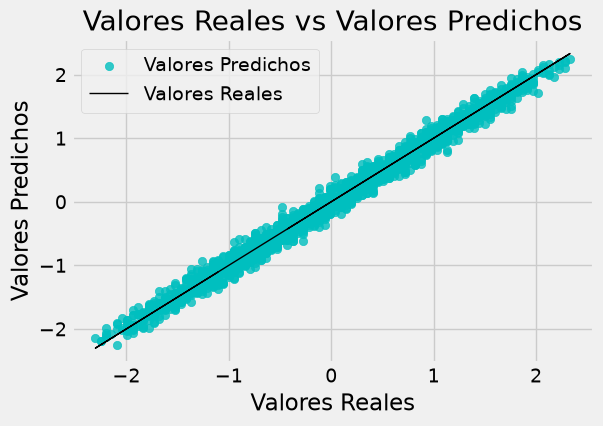

In [48]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(y_test, y_pred, c="c", alpha=0.8, label="Valores Predichos")

ax.plot(y_test, y_test, c="k", lw=1, label="Valores Reales")

ax.set_xlabel('Valores Reales')
ax.set_ylabel('Valores Predichos')
ax.set_title('Valores Reales vs Valores Predichos')
ax.legend()

## 19. Predicción con un nuevo dato
Se utiliza el modelo entrenado para predecir el índice de rendimiento de un estudiante nuevo, a partir de un conjunto de valores de entrada definido manualmente.


In [49]:
input_data = np.array([[7, 99, 0, 9, 1]]) 

y_pred = model.predict(input_data)

print("Índice de Rendimiento Predicho:", y_pred[0])

Índice de Rendimiento Predicho: [93.89895519]


**Nota:** Aquí se prueba el modelo con un estudiante inventado para ver qué predice. Sin embargo, creo que esta celda tiene un problema: más arriba los datos se escalaron (normalizaron) antes de entrenar el modelo, pero aquí se le pasan los valores "tal cual", sin escalar y creo que también en un orden distinto al que se usó para entrenar. Por eso pienso que el resultado de esta predicción probablemente no sea muy confiable. 

## 20. Importancia de las variables (coeficientes del modelo)
Se examinan los coeficientes e intercepto del modelo para entender cómo influye cada variable en la predicción, y se visualiza la importancia relativa de cada una en un gráfico de barras horizontales.


In [50]:
model.coef_

array([[0.384283  , 0.91859613, 0.04172256, 0.0281672 , 0.02987479]])

In [51]:
model.intercept_

array([-0.01542187])

In [52]:
def feature_importance_df():
    coef = model.coef_.reshape(-1)  
    features = X.columns.tolist()  
    
    return pd.DataFrame({'Features': features, 'Coefficients': coef})

feature_importance = feature_importance_df()


In [53]:
feature_importance.groupby('Features')['Coefficients'].max().sort_values(ascending = False)

Features
Previous Scores                     0.918596
Hours Studied                       0.384283
Extracurricular Activities          0.041723
Sample Question Papers Practiced    0.029875
Sleep Hours                         0.028167
Name: Coefficients, dtype: float64

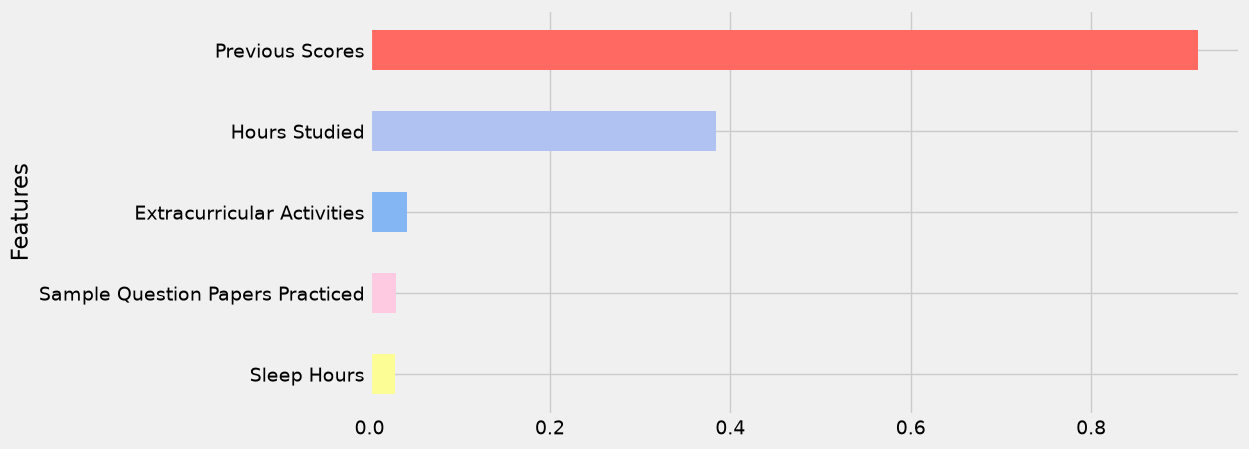

In [54]:
fig = plt.subplots(1,1,figsize = (10,5))

feature_importance.groupby('Features')['Coefficients'].max().sort_values(ascending = True).plot(kind = 'barh',
                                                                                                color = ['#fdfd96','#fdcae1',
                                                                                                         '#84b6f4','#b0c2f2',                                                                                                       '#ff6961','#77dd77'])
plt.show()

## 21. Guardado del modelo entrenado
Se guarda el modelo entrenado en un archivo (`linear_model.pkl`) usando `joblib`, para poder reutilizarlo más adelante sin necesidad de volver a entrenarlo.


In [55]:
import joblib
joblib.dump(model,'linear_model.pkl')

['linear_model.pkl']